In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import torch
import pytorch_lightning as pl
from scdiff.dataset import ScDataModule
from scdiff.ae import LightningAE
import scanpy as sc
import os
from scdiff.plot import compare_umap, umap_plot
from scdiff.transform import NormalLog1pScaler

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/tqdm/auto.py:21: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')
muris

AnnData object with n_obs × n_vars = 57004 × 18996
    obs: 'celltype', 'n_genes', 'counts'
    var: 'n_cells'

In [4]:
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)
sc.pp.normalize_total(muris, target_sum=1e4)
sc.pp.log1p(muris)

In [ ]:
murisData = ScDataModule(muris, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=muris.X.shape[1])

log_dir = "lightning_logs/muris/ae"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

trainer = pl.Trainer(
    max_epochs=200, # may need more training
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir=log_dir
)

ae_path = "checkpoints/muris/trained_ae.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, murisData)
    trainer.save_checkpoint(ae_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [6]:
device = next(ae.parameters()).device
X_tensor = torch.tensor(muris.X.toarray(), dtype=torch.float32, device=device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()   

encoded_muris = ad.AnnData(X_encoded, obs=muris.obs.copy())

In [8]:
# umap_plot(X_encoded, muris.obs["celltype"])

In [9]:
# sc.pp.neighbors(encoded_muris, n_neighbors=10, n_pcs=20)
# sc.tl.umap(encoded_muris)
# sc.pl.umap(encoded_muris, color="celltype", title="UMAP of encoded muris")

In [ ]:
from sklearn.preprocessing import StandardScaler
from scdiff.lightning_diffusion import LightningDiffusion

# IMPORTANT: diffusion training is much more stable if latents are standardized.
# We fit the scaler on the real AE latents, train diffusion_standardized_standardized_standardized in the scaled space,
# and inverse-transform generated samples back to the AE latent space before decoding.
# standard_scaler = StandardScaler()
# scaled_X_encoded = standard_scaler.fit_transform(X_encoded)
# encoded_muris.X = scaled_X_encoded

latent_dm = ScDataModule(
    encoded_muris,
    label_key="celltype",
    encoder="LabelEncoder",
    batch_size=128,
    val_split=0.1,
    balanced_sampling = False,
)
latent_dm.setup()

dim = encoded_muris.X.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999
)

trainer = pl.Trainer(
    max_epochs=150,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/muris/diffusion",
)

diffusion_model_path = "checkpoints/muris/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [10]:
import numpy as np

diffusion.eval()

# Sample labels from the *training* label distribution.
# If you pass labels=None, you are doing pure unconditional sampling, but the model
# only sees unconditional branch with probability = guidance_dropout during training.
train_idx = latent_dm.train_dataset.indices
train_labels = np.array(latent_dm.train_dataset.dataset.classes)[train_idx]
sampled_labels = torch.tensor(
    np.random.choice(train_labels, size=10000, replace=True),
    dtype=torch.long,
    device=diffusion.device,
)

diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(num_samples=10000,
                                    sampling_timesteps=100,
                                    ddim_sampling_eta=0.0,
                                    use_ema=True,
                                    clip_denoised=False)

DDIM sampling: 100%|██████████| 100/100 [01:02<00:00,  1.60it/s]


In [13]:
latent_samples_t = torch.tensor(latent_samples).to(device=device, dtype=torch.float32)
decoded_samples = ae.decode(latent_samples_t)

/var/folders/5z/8hzvmhln5p36t4tdqc9c52z40000gn/T/ipykernel_1178/1008693912.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  latent_samples_t = torch.tensor(latent_samples).to(device=device, dtype=torch.float32)


In [14]:
import numpy as np
samples_baseline = np.load('../data/comparisons/sim_muris_decoded.npy')    
samples_baseline.shape 

(10000, 18996)

In [15]:
decoded_samples = decoded_samples.detach().cpu().numpy()
decoded_samples

array([[-6.54899979e+00,  3.89636016e+00,  3.42059822e+01, ...,
        -9.36993504e+00,  3.46158147e+00, -1.18458402e+00],
       [-1.19978279e+02,  7.35128098e+01,  3.61687317e+02, ...,
        -1.40344376e+02,  4.34672928e+01,  2.43387665e+02],
       [-1.17237175e+02,  6.40825195e+01,  5.79439049e+01, ...,
        -1.15751434e+02,  7.28044357e+01,  6.70246582e+02],
       ...,
       [ 9.32627678e+00,  2.59459674e-01,  1.90020523e+01, ...,
         9.55680656e+00,  1.67009377e+00,  2.19316742e+02],
       [-6.98219604e+01,  5.74564362e+01,  2.79222240e+01, ...,
        -7.65851898e+01,  3.39395065e+01,  3.05816059e+01],
       [-1.13684189e+02,  5.94088173e+01,  2.89433784e+01, ...,
        -1.08054665e+02,  5.83846741e+01,  4.60889191e+02]],
      shape=(10000, 18996), dtype=float32)

Performing UMAP on combined dataset (20000 samples, 18996 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 1.1561714e+01, -2.9485292e+00],
         [ 1.9455238e+01,  7.8506684e-03],
         [ 1.1940839e+01, -2.4579492e+00],
         ...,
         [ 1.3792484e+01, -2.5889728e+00],
         [ 1.9319740e+01, -3.1148455e-01],
         [ 1.9619570e+01,  5.2405863e+00]], shape=(10000, 2), dtype=float32),
  array([[ 1.9081212, 12.391774 ],
         [-0.9410111,  9.429171 ],
         [-5.7247753,  2.573834 ],
         ...,
         [-2.0130193,  9.119321 ],
         [ 1.8781844, 10.726472 ],
         [-5.9667816,  1.9214668]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

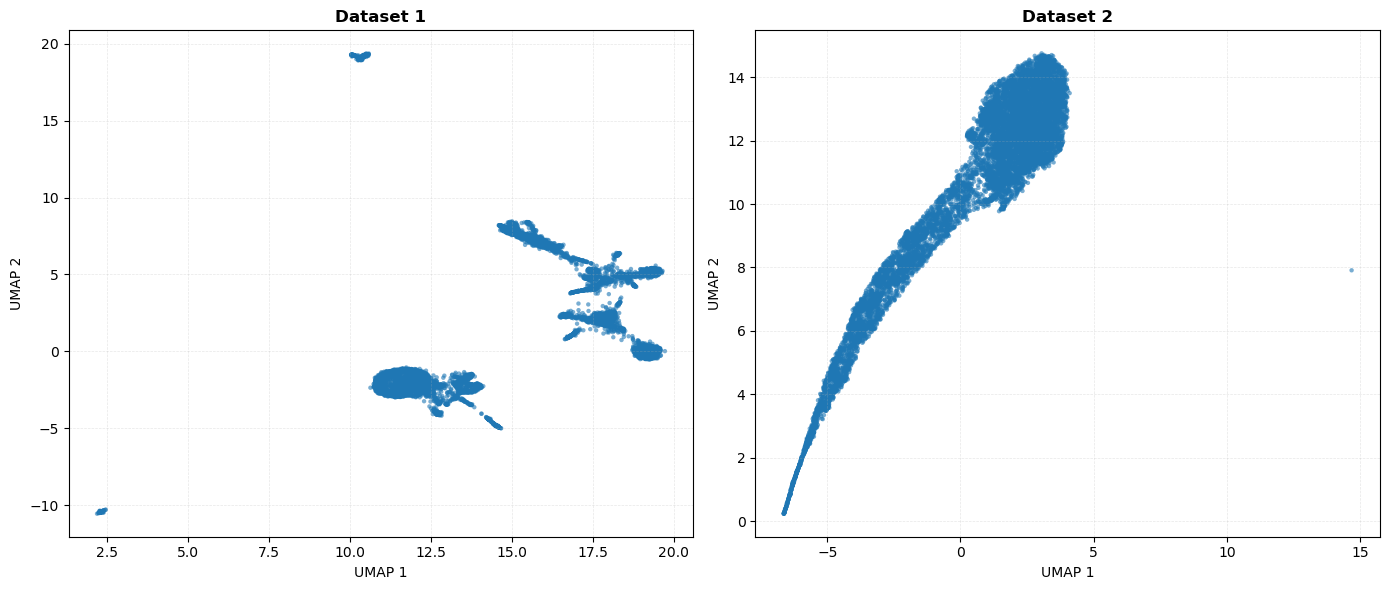

In [16]:
muris_10k = muris.X.toarray()[np.random.choice(muris.n_obs, 10000, replace=False)]
compare_umap([muris_10k, decoded_samples])

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 9.842562  , -3.5358026 ],
         [ 0.25993595,  0.7119324 ],
         [13.394081  ,  6.608062  ],
         ...,
         [11.389318  , -5.4279995 ],
         [-0.19879842,  4.9765706 ],
         [ 0.42877516, -0.64352393]], shape=(10000, 2), dtype=float32),
  array([[10.506724 , 20.881603 ],
         [-7.6734543, 11.437686 ],
         [-8.651283 , 16.018581 ],
         ...,
         [-8.502965 , 12.429496 ],
         [ 8.047939 , 21.08261  ],
         [-8.587376 , 16.376825 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

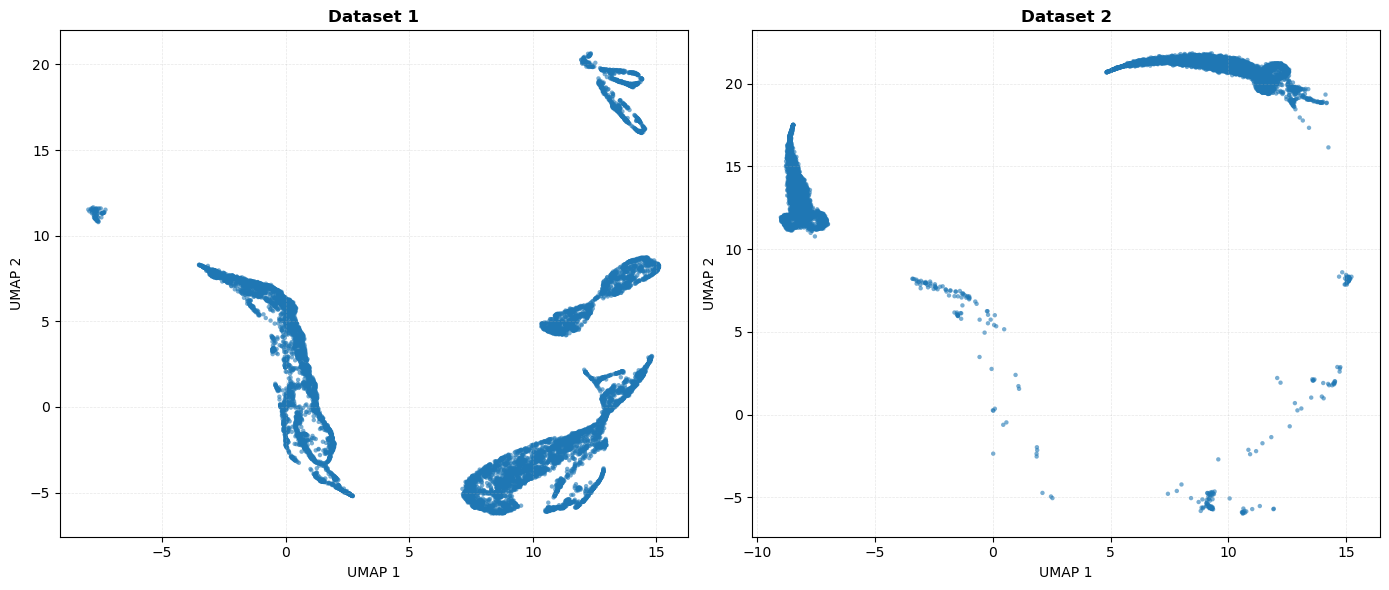

In [17]:
encoded_10k = X_encoded[np.random.choice(X_encoded.shape[0], 10000, replace=False)]
compare_umap([encoded_10k, latent_samples])

Performing UMAP on combined dataset (20000 samples, 18996 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 5.7978034, -4.3973565],
         [10.981915 ,  5.201743 ],
         [ 4.9332323, -6.1351185],
         ...,
         [19.929731 , -5.6634355],
         [10.612106 ,  6.9587903],
         [16.812014 ,  6.3357   ]], shape=(10000, 2), dtype=float32),
  array([[10.307185 ,  6.56711  ],
         [18.9266   , -2.4768689],
         [ 6.462481 , -4.595534 ],
         ...,
         [20.203472 , -5.5450025],
         [ 6.995916 , -4.6523685],
         [13.438055 , -5.415089 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

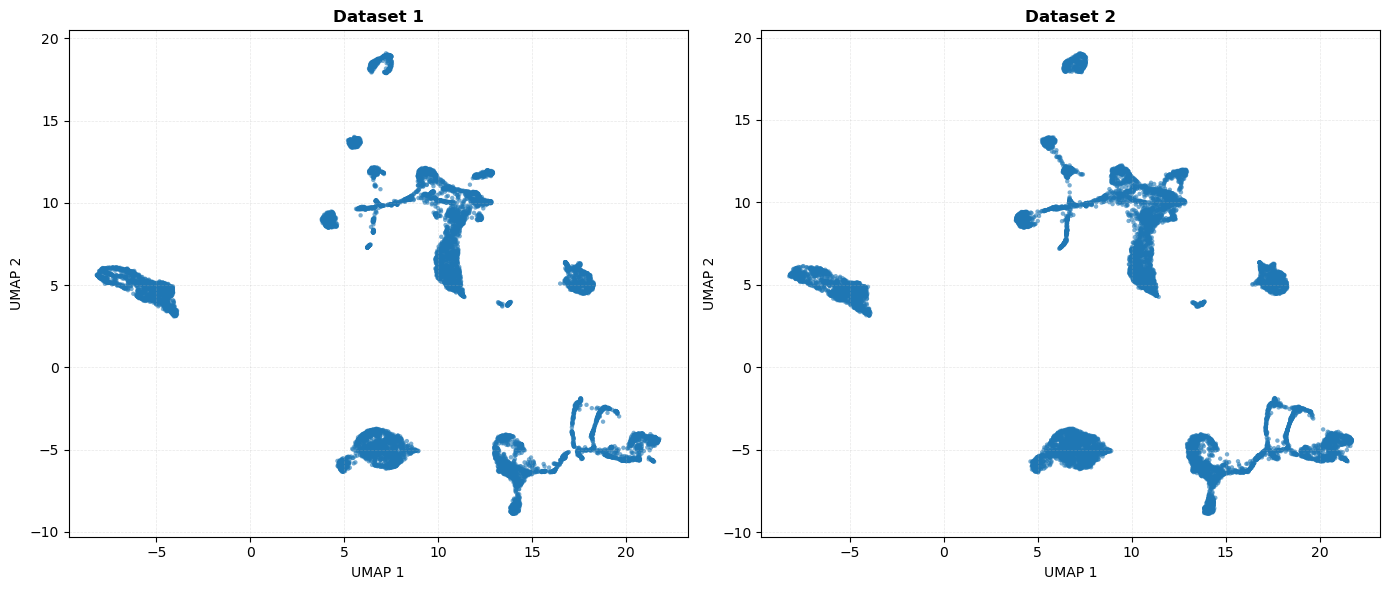

In [18]:
compare_umap([muris_10k, samples_baseline])

## Training an unconditional diffusion model with standardized latents

In [ ]:
standard_scaler = StandardScaler()
scaled_X_encoded = standard_scaler.fit_transform(X_encoded)
encoded_muris.X = scaled_X_encoded

scaled_latent_dm = ScDataModule(
    encoded_muris,
    label_key="celltype",
    encoder="LabelEncoder",
    batch_size=128,
    val_split=0.1,
    balanced_sampling = False,
)
scaled_latent_dm.setup()

dim = encoded_muris.X.shape[1]
num_classes = int(scaled_latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion_standardized = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999,
    guidance_dropout = 0.8
)

trainer = pl.Trainer(
    max_epochs=200,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/muris/diffusion",
)

diffusion_model_path = "checkpoints/muris/standardized_trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion_standardized = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion_standardized, scaled_latent_dm)
    trainer.save_checkpoint(diffusion_model_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | DenoisingUNet     | 7.2 M  | train
1 | diffusion | GaussianDiffusion | 7.2 M  | train
2 | ema_model | DenoisingUNet     | 7.2 M  | eval 
--------------------------------------------------------
7.2 M     Trainable params
7.2 M     Non-trainable params
14.3 M    Total params
57.378    Total estimated model params size (MB)
92        Modules in train mode
91        Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:527: Found 91 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 199: 100%|██████████| 401/401 [00:17<00:00, 22.59it/s, v_num=3, val_loss=0.035, train_loss=0.0371] 

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 401/401 [00:18<00:00, 22.14it/s, v_num=3, val_loss=0.035, train_loss=0.0371]


In [ ]:
diffusion_standardized.eval()

with torch.no_grad():
    standardized_latent_samples = diffusion_standardized.sample(num_samples=10000,
                                      sampling_timesteps=100,
                                      ddim_sampling_eta=0.0,
                                      use_ema=True,
                                      clip_denoised=False)

DDIM sampling: 100%|██████████| 100/100 [02:12<00:00,  1.33s/it]


ValueError: Feature dimensions must match across datasets: dataset 0 has 18996 features, dataset 1 has 128 features

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[10.961992 , 23.62364  ],
         [ 6.3477807, 13.157665 ],
         [16.134212 ,  8.963457 ],
         ...,
         [ 8.896966 , 25.969269 ],
         [ 6.149271 , 18.45114  ],
         [ 6.2573028, 12.990541 ]], shape=(10000, 2), dtype=float32),
  array([[ 9.442824 , 26.989475 ],
         [ 7.3191404, 29.222105 ],
         [ 8.376018 , 29.309763 ],
         ...,
         [ 7.1985254, 29.638548 ],
         [ 9.595359 , 27.064642 ],
         [ 6.9849076, 27.47171  ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

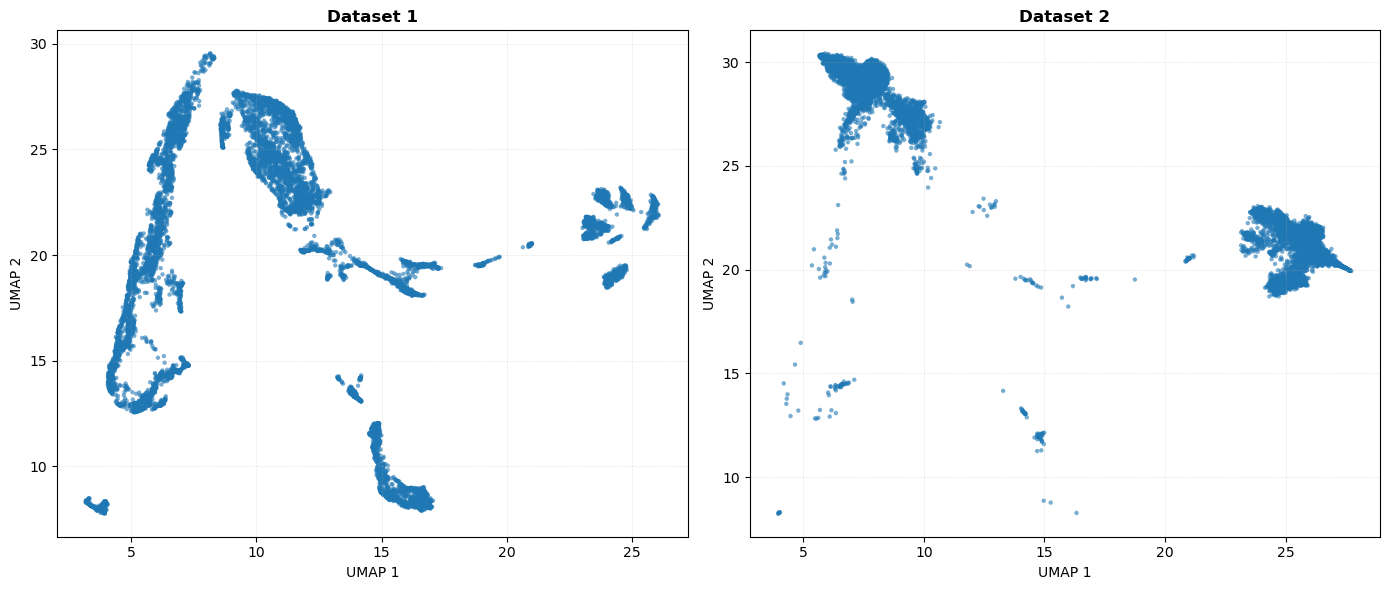

In [ ]:
scaled_encoded_10k = standard_scaler.transform(encoded_10k)
compare_umap([scaled_encoded_10k, standardized_latent_samples])

sampling loop time step: 100%|██████████| 1000/1000 [14:11<00:00,  1.17it/s]
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...
UMAP completed. Generating visualizations...


([array([[16.625967  ,  5.826757  ],
         [ 9.43604   ,  1.7073524 ],
         [15.297534  , -3.4320612 ],
         ...,
         [18.415815  ,  3.613353  ],
         [ 8.874351  ,  6.5714808 ],
         [ 9.966941  ,  0.28702307]], shape=(10000, 2), dtype=float32),
  array([[-6.5263977 ,  4.2154665 ],
         [ 3.1616833 ,  3.1283402 ],
         [ 1.8050779 , -0.50414306],
         ...,
         [ 0.64191914,  8.980125  ],
         [ 2.0696554 ,  5.2608566 ],
         [ 1.328691  , -7.107254  ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

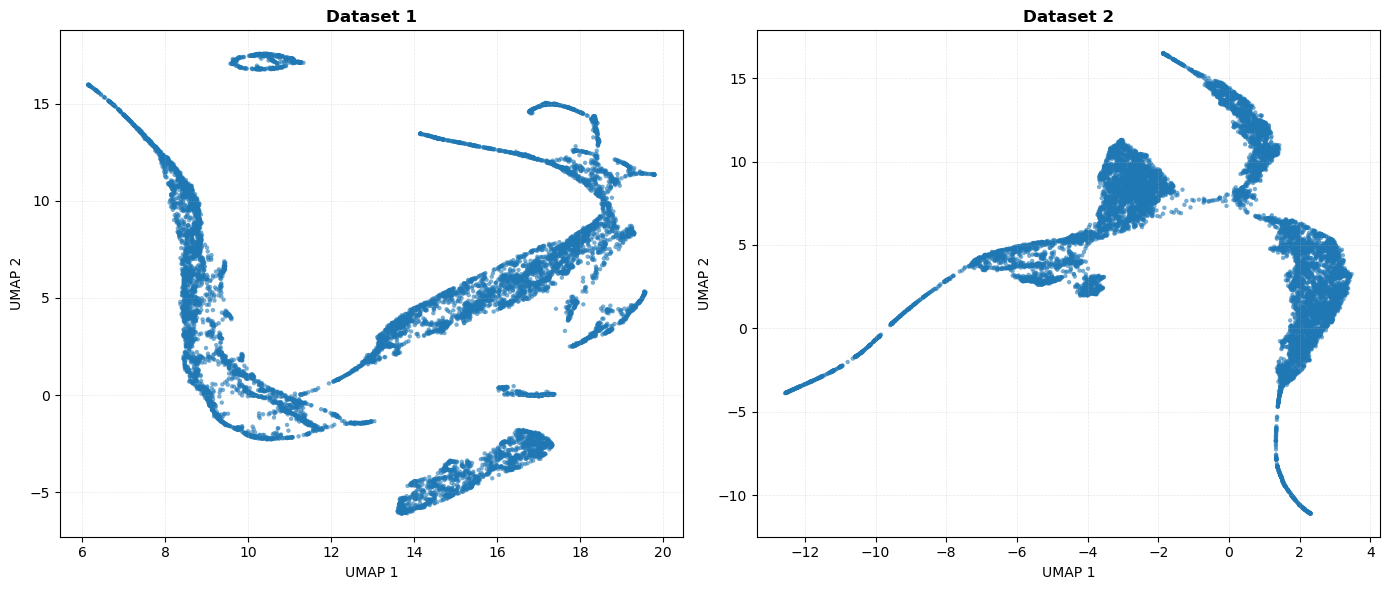

In [ ]:
# full ddpm sampling
with torch.no_grad():
    standardized_latent_ddpm_samples = diffusion_standardized.sample(num_samples=10000,
                                                sampling_timesteps=1000,
                                                ddim_sampling_eta=0.5,
                                                use_ema=True,
                                                clip_denoised=False)
compare_umap([encoded_10k, standardized_latent_ddpm_samples])

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 6.039893  , -4.285698  ],
         [-4.5544157 ,  3.2769287 ],
         [-0.34298626, -1.2478671 ],
         ...,
         [ 1.3886516 , -4.1995387 ],
         [-2.9880888 ,  6.3065095 ],
         [-4.8135567 ,  2.3846314 ]], shape=(10000, 2), dtype=float32),
  array([[11.664439 ,  2.2296338],
         [-6.054185 ,  4.6450124],
         [-1.3084366,  7.612712 ],
         ...,
         [ 0.5777192, -5.0710506],
         [-6.1188087,  1.4782604],
         [ 2.4814258, 14.008354 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

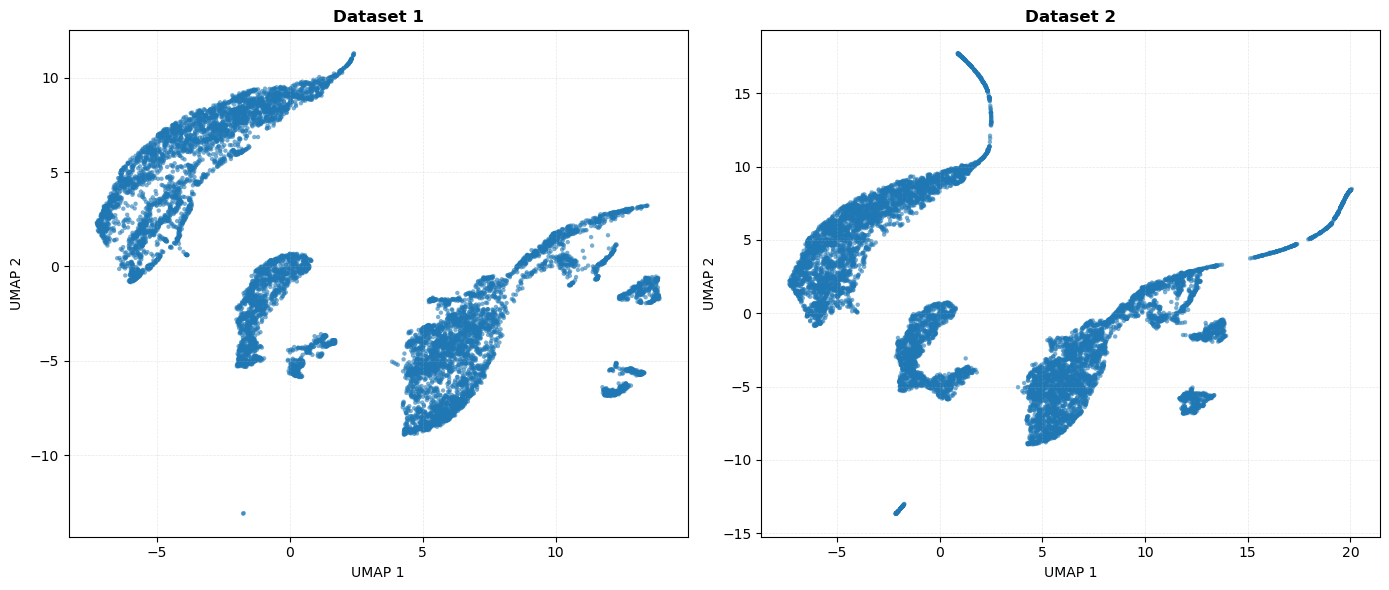

In [ ]:
compare_umap([scaled_encoded_10k, standardized_latent_ddpm_samples])

Performing UMAP on combined dataset (20000 samples, 18996 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[24.993826, 14.82469 ],
         [12.42639 , 16.100672],
         [24.306139, 15.0021  ],
         ...,
         [24.782616, 16.641724],
         [10.671074,  8.486348],
         [10.983292, 10.484976]], shape=(10000, 2), dtype=float32),
  array([[ 7.937639  ,  3.9963593 ],
         [-1.6649231 ,  6.4247375 ],
         [-4.7519326 ,  8.211671  ],
         ...,
         [ 3.5350368 ,  6.6163864 ],
         [ 0.85853666,  6.468874  ],
         [-9.2553835 ,  7.941609  ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

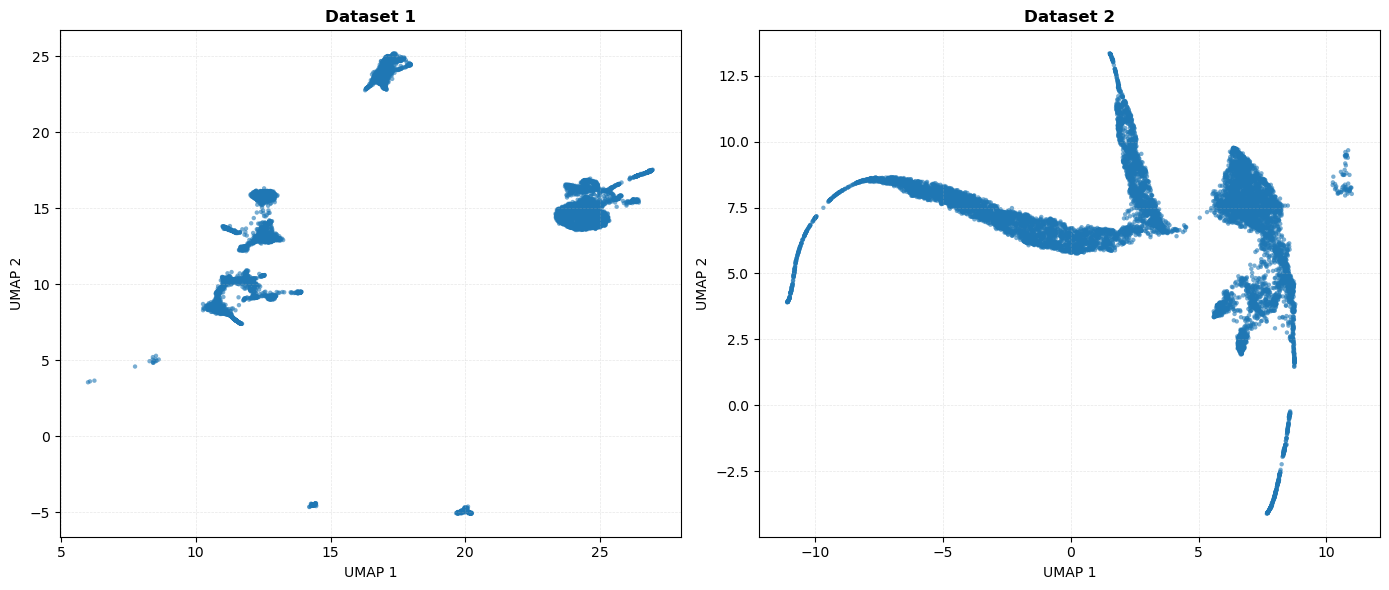

In [ ]:
invered_ddpm_samples = standard_scaler.inverse_transform(standardized_latent_ddpm_samples)

with torch.no_grad():
    decoded_ddpm_samples = ae.decode(torch.tensor(invered_ddpm_samples).to(device=device, dtype=torch.float32))
    
compare_umap([muris_10k, decoded_ddpm_samples])


Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[12.527467 ,  5.165225 ],
         [12.139375 , 14.475791 ],
         [ 5.0508523,  3.092654 ],
         ...,
         [15.361382 ,  7.67487  ],
         [ 3.2308407, 15.972032 ],
         [12.77292  , 14.475698 ]], shape=(10000, 2), dtype=float32),
  array([[ 9.63913   , -7.122018  ],
         [11.08317   , 15.423769  ],
         [ 0.57027084, 14.666508  ],
         ...,
         [ 9.684725  ,  3.6882908 ],
         [16.057915  , 12.018399  ],
         [-3.943395  ,  2.3859224 ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

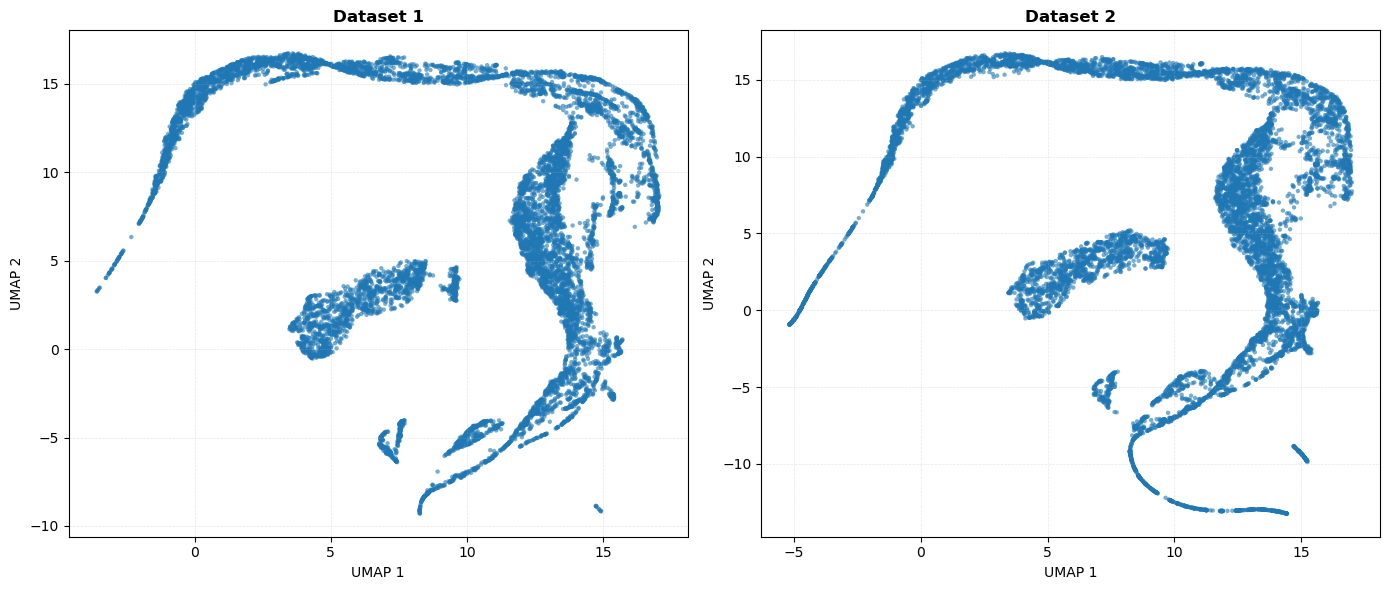

In [34]:
compare_umap([encoded_10k, invered_ddpm_samples]) 